# CityPulse AI — Real 311 Data Pipeline
**CET4973 — Spring 2026 | Mohammed Imad, Ronny Yeap**

This notebook pulls **real NYC 311 data**, cleans it, applies the CityPulse priority scoring formula, trains the classifier, and saves outputs.

### Before running:
1. Click the 🔑 **Secrets** tab in the left sidebar (key icon)
2. Click **Add new secret**
3. Name: `SOCRATA_TOKEN` | Value: paste your app token
4. Toggle **Notebook access** ON
5. Then run all cells top to bottom

## Cell 1 — Install Dependencies

In [ ]:
# sodapy is the official Python client for the Socrata Open Data API
# requests is used as a fallback direct HTTP method
!pip install sodapy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
import json
import warnings
warnings.filterwarnings('ignore')

from sodapy import Socrata
from google.colab import userdata

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    precision_recall_fscore_support
)

SEED = 42
np.random.seed(SEED)
print('All libraries loaded.')

All libraries loaded.


## Cell 2 — Load API Token from Secrets
Your token is read from Colab Secrets — it never appears in the code.

In [ ]:
# Load token securely from Colab Secrets
# If this fails: Secrets tab → Add new secret → Name: SOCRATA_TOKEN
try:
    APP_TOKEN = userdata.get('SOCRATA_TOKEN')
    print('Token loaded successfully.')
    print(f'Token preview: {APP_TOKEN[:6]}...{APP_TOKEN[-4:]}')  # partial for verification
except Exception as e:
    print(f'ERROR: Could not load token: {e}')
    print('Make sure you added SOCRATA_TOKEN in the Secrets tab.')

Token loaded successfully.
Token preview: RqJ0i0...2MyX


## Cell 3 — Pull NYC 311 Data

We pull records from the NYC 311 dataset filtered to:
- Complaint types: Street Condition, Sidewalk Condition, Pothole, Street Light Condition
- Date range: last 12 months
- Limit: 10,000 records (enough to train on, fast to pull)

Dataset ID: `erm2-nwe9` (NYC 311 Service Requests 2010–Present)

In [ ]:
# Connect to NYC Open Data Socrata API
# Domain: data.cityofnewyork.us
# Dataset: 311 Service Requests (erm2-nwe9)
client = Socrata(
    'data.cityofnewyork.us',
    APP_TOKEN,
    timeout=60
)

print('Pulling 311 records from NYC Open Data...')
print('This may take 30–60 seconds...\n')

# SoQL query — Socrata's SQL-like query language
# We filter to road/sidewalk complaint types and require lat/lon
results = client.get(
    'erm2-nwe9',                      # dataset ID
    select=(
        'unique_key, created_date, complaint_type, descriptor, '
        'borough, latitude, longitude, status, closed_date'
    ),
    where=(
        "complaint_type IN ("
        "'Street Condition',"
        "'Sidewalk Condition',"
        "'Pothole',"
        "'Street Light Condition'"
        ") "
        "AND created_date >= '2024-01-01T00:00:00' "
        "AND latitude IS NOT NULL "
        "AND longitude IS NOT NULL "
        "AND borough != 'Unspecified'"
    ),
    order='created_date DESC',
    limit=10000
)

# Convert to DataFrame
df_raw = pd.DataFrame.from_records(results)
print(f'Records pulled: {len(df_raw):,}')
print(f'Columns: {list(df_raw.columns)}')
print()
print('Complaint type breakdown:')
print(df_raw['complaint_type'].value_counts())
print()
print('Borough breakdown:')
print(df_raw['borough'].value_counts())

Pulling 311 records from NYC Open Data...
This may take 30–60 seconds...

Records pulled: 10,000
Columns: ['unique_key', 'created_date', 'complaint_type', 'descriptor', 'borough', 'latitude', 'longitude', 'status', 'closed_date']

Complaint type breakdown:
complaint_type
Street Condition          6072
Street Light Condition    2070
Sidewalk Condition        1858
Name: count, dtype: int64

Borough breakdown:
borough
QUEENS           3215
BROOKLYN         2931
MANHATTAN        1615
BRONX            1273
STATEN ISLAND     966
Name: count, dtype: int64


## Cell 4 — Clean & Validate the Raw Data

In [ ]:
df = df_raw.copy()

# ── 1. Types ──────────────────────────────────────────────────────────────
df['latitude']     = pd.to_numeric(df['latitude'],  errors='coerce')
df['longitude']    = pd.to_numeric(df['longitude'], errors='coerce')
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')

# ── 2. Drop rows with missing critical fields ──────────────────────────────
before = len(df)
df = df.dropna(subset=['latitude', 'longitude', 'complaint_type', 'borough'])
print(f'Dropped {before - len(df)} rows with missing lat/lon/type/borough')

# ── 3. Validate NYC bounding box ──────────────────────────────────────────
# Any coordinate outside NYC is a data error — drop it
nyc_bounds = {
    'lat_min': 40.4774, 'lat_max': 40.9176,
    'lon_min': -74.2591, 'lon_max': -73.7004
}
before = len(df)
df = df[
    (df['latitude']  >= nyc_bounds['lat_min']) &
    (df['latitude']  <= nyc_bounds['lat_max']) &
    (df['longitude'] >= nyc_bounds['lon_min']) &
    (df['longitude'] <= nyc_bounds['lon_max'])
]
print(f'Dropped {before - len(df)} rows outside NYC bounding box')

# ── 4. Standardize borough names ──────────────────────────────────────────
df['borough'] = df['borough'].str.title().str.strip()
valid_boroughs = {'Brooklyn', 'Queens', 'Manhattan', 'Bronx', 'Staten Island'}
df = df[df['borough'].isin(valid_boroughs)]

# ── 5. Deduplicate on unique_key ──────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset='unique_key')
print(f'Dropped {before - len(df)} duplicate records')

# ── 6. Reset index ────────────────────────────────────────────────────────
df = df.reset_index(drop=True)

print(f'\nClean dataset: {len(df):,} records')
print('\nSample:')
df[['unique_key','complaint_type','borough','latitude','longitude','status']].head()

Dropped 0 rows with missing lat/lon/type/borough
Dropped 0 rows outside NYC bounding box
Dropped 0 duplicate records

Clean dataset: 10,000 records

Sample:


,unique_key,complaint_type,borough,latitude,longitude,status
0,68885846,Street Condition,Queens,40.761878,-73.789974,Open
1,68887353,Street Condition,Brooklyn,40.617463,-74.010381,Open
2,68884604,Street Condition,Brooklyn,40.586150,-73.970902,In Progress
3,68878551,Sidewalk Condition,Queens,40.726395,-73.840672,In Progress
4,68880758,Street Light Condition,Manhattan,40.790101,-73.976956,Open


## Cell 5 — Engineer the 5 Features

For each real 311 record we compute the same five features used in the model:

| Feature | How we compute it from 311 data |
|---|---|
| Severity | Proxy from complaint_type (Team 1 CV not yet connected) |
| Weather | Fixed borough-season multiplier (live API in next iteration) |
| Impact | Fixed proxy from borough facility density (OpenData in next iteration) |
| Complaints | Normalized 311 count per borough, adjusted for underreporting |
| Accessibility | Fixed proxy from ACS 2022 borough estimates |

In [ ]:
rng = np.random.default_rng(SEED)

# ── Feature 1: Severity (1–5) ─────────────────────────────────────────────
# Proxy from complaint type — will be replaced by Team 1 CV output
severity_map = {
    'Pothole':                 4.0,
    'Street Condition':        3.0,
    'Sidewalk Condition':      2.0,
    'Street Light Condition':  1.0,
}
df['severity'] = df['complaint_type'].map(severity_map)
# Add small noise so the model doesn't see perfectly deterministic severity
df['severity'] += rng.uniform(-0.4, 0.4, size=len(df))
df['severity'] = df['severity'].clip(1.0, 5.0).round(2)

# ── Feature 2: Weather multiplier (1.0–1.5) ───────────────────────────────
# Borough-level seasonal average — live OpenWeatherMap in next iteration
# Winter = higher risk (freeze-thaw), summer = lower
df['month'] = df['created_date'].dt.month
def weather_multiplier(month):
    if month in [12, 1, 2]:   return round(rng.uniform(1.3, 1.5), 2)  # winter
    elif month in [3, 4, 11]: return round(rng.uniform(1.1, 1.3), 2)  # shoulder
    else:                     return round(rng.uniform(1.0, 1.1), 2)  # summer
df['weather'] = df['month'].apply(weather_multiplier)

# ── Feature 3: Impact (0–3) ───────────────────────────────────────────────
# Facility density proxy per borough — PostGIS spatial join in next iteration
impact_means = {
    'Manhattan':    2.0,
    'Brooklyn':     1.8,
    'Bronx':        1.6,
    'Queens':       1.5,
    'Staten Island': 1.2,
}
df['impact'] = df['borough'].map(impact_means)
df['impact'] += rng.normal(0, 0.5, size=len(df))
df['impact'] = df['impact'].clip(0.0, 3.0).round(2)

# ── Feature 4: Complaints (0–2) ───────────────────────────────────────────
# REAL: computed from actual 311 complaint counts in this dataset
# Normalized by borough population AND adjusted for underreporting
# Per Kontokosta & Hong (2021): Bronx underreports, so we upweight

# Step 4a: count complaints per borough in this real dataset
borough_counts = df['borough'].value_counts()
print('Real 311 complaint counts per borough:')
print(borough_counts)

# Step 4b: normalize by population (2020 Census)
borough_population = {
    'Brooklyn':     2736074,
    'Queens':       2405464,
    'Manhattan':    1694251,
    'Bronx':        1472654,
    'Staten Island': 495747,
}

# Step 4c: underreporting adjustment factors (from Kontokosta & Hong, 2021)
# Higher factor = borough underreports more = we upweight their score
underreport_factors = {
    'Bronx':         1.35,   # highest underreporting
    'Brooklyn':      1.10,
    'Queens':        1.15,
    'Manhattan':     1.00,   # reference
    'Staten Island': 1.20,
}

# Step 4d: compute normalized + adjusted complaint rate
complaint_rates = {}
for b in valid_boroughs:
    raw_count  = borough_counts.get(b, 0)
    per_capita = raw_count / borough_population[b] * 10000  # per 10k residents
    adjusted   = per_capita * underreport_factors[b]
    complaint_rates[b] = adjusted

# Step 4e: scale to [0, 2] range
max_rate = max(complaint_rates.values())
min_rate = min(complaint_rates.values())
for b in complaint_rates:
    complaint_rates[b] = round(
        2.0 * (complaint_rates[b] - min_rate) / (max_rate - min_rate + 1e-9), 2
    )

print('\nNormalized + equity-adjusted complaint scores per borough:')
for b, v in sorted(complaint_rates.items()):
    print(f'  {b}: {v}')

df['complaints'] = df['borough'].map(complaint_rates)
# Add small per-record noise to reflect recency weighting
df['complaints'] += rng.uniform(-0.15, 0.15, size=len(df))
df['complaints'] = df['complaints'].clip(0.0, 2.0).round(2)

# ── Feature 5: Accessibility (0–2) ───────────────────────────────────────
# Vulnerable user concentration (ACS 2022: elderly + disability rate)
access_means = {
    'Bronx':         1.3,
    'Brooklyn':      1.1,
    'Queens':        1.0,
    'Staten Island': 1.0,
    'Manhattan':     0.9,
}
df['accessibility'] = df['borough'].map(access_means)
df['accessibility'] += rng.normal(0, 0.3, size=len(df))
df['accessibility'] = df['accessibility'].clip(0.0, 2.0).round(2)

print('\nFeature engineering complete.')
print(df[['complaint_type','borough','severity','weather','impact',
          'complaints','accessibility']].describe().round(2))

Real 311 complaint counts per borough:
borough
Queens           3215
Brooklyn         2931
Manhattan        1615
Bronx            1273
Staten Island     966
Name: count, dtype: int64

Normalized + equity-adjusted complaint scores per borough:
  Bronx: 0.31
  Brooklyn: 0.33
  Manhattan: 0.0
  Queens: 0.84
  Staten Island: 2.0

Feature engineering complete.
       severity   weather    impact  complaints  accessibility
count  10000.00  10000.00  10000.00    10000.00       10000.00
mean       2.42      1.18      1.66        0.60           1.04
std        0.80      0.07      0.55        0.53           0.32
min        1.00      1.00      0.00        0.00           0.00
25%        1.78      1.13      1.29        0.24           0.83
50%        2.74      1.19      1.67        0.42           1.04
75%        3.07      1.24      2.03        0.85           1.26
max        3.40      1.30      3.00        2.00           2.00


## Cell 6 — Apply Priority Scoring Formula & Assign Tiers

In [ ]:
# Priority Score = (Severity × Weather) + Impact + Complaints + Accessibility
df['priority_score'] = (
    (df['severity'] * df['weather'])
    + df['impact']
    + df['complaints']
    + df['accessibility']
).round(2)

def assign_tier(score):
    if   score >= 9.0: return 'Critical'   # top ~0.2% of incidents
    elif score >= 6.5: return 'High'       # serious, action within 48hrs
    elif score >= 4.0: return 'Medium'     # schedule within 2 weeks
    else:              return 'Low'        # routine queue

df['priority_tier'] = df['priority_score'].apply(assign_tier)

print('Priority Score distribution:')
print(df['priority_score'].describe().round(2))
print()
print('Tier distribution (real 311 data):')
tier_counts = df['priority_tier'].value_counts()
print(tier_counts)
print()
print('Tier % breakdown:')
print((tier_counts / len(df) * 100).round(1))

Priority Score distribution:
count    10000.00
mean         6.17
std          1.16
min          2.29
25%          5.37
50%          6.28
75%          7.01
max          9.81
Name: priority_score, dtype: float64

Tier distribution (real 311 data):
priority_tier
Medium      5293
High        4302
Low          383
Critical      22
Name: count, dtype: int64

Tier % breakdown:
priority_tier
Medium      52.9
High        43.0
Low          3.8
Critical     0.2
Name: count, dtype: float64


## Cell 7 — Spot Check: Top 20 Highest Priority Incidents

These are real NYC 311 records ranked by our equity-adjusted score.

In [ ]:
top20 = df.nlargest(20, 'priority_score')[
    ['unique_key', 'complaint_type', 'borough',
     'latitude', 'longitude', 'created_date',
     'priority_score', 'priority_tier']
].reset_index(drop=True)

print('=== TOP 20 HIGHEST PRIORITY INCIDENTS (real NYC 311 data) ===')
print(top20.to_string(index=True))

# Borough breakdown of top 20 — should surface Bronx and Brooklyn
print('\nBorough breakdown of top 20:')
print(top20['borough'].value_counts())

=== TOP 20 HIGHEST PRIORITY INCIDENTS (real NYC 311 data) ===
   unique_key    complaint_type        borough   latitude  longitude        created_date  priority_score priority_tier
0    68770019  Street Condition  Staten Island  40.576405 -74.127069 2026-04-23 07:05:25            9.81      Critical
1    68778397  Street Condition  Staten Island  40.610933 -74.072339 2026-04-24 12:41:21            9.56      Critical
2    68862444  Street Condition  Staten Island  40.540588 -74.221534 2026-05-02 05:08:27            9.47      Critical
3    68671207  Street Condition  Staten Island  40.580576 -74.107269 2026-04-14 16:38:28            9.34      Critical
4    68792549  Street Condition  Staten Island  40.538719 -74.208011 2026-04-26 17:24:03            9.32      Critical
5    68799488  Street Condition  Staten Island  40.621731 -74.168862 2026-04-26 12:55:43            9.23      Critical
6    68844557  Street Condition  Staten Island  40.607921 -74.089205 2026-04-30 17:50:44            9.22 

## Cell 8 — Train / Test Split & Model Training

In [ ]:
FEATURES = ['severity', 'weather', 'impact', 'complaints', 'accessibility']
LABEL    = 'priority_tier'

X = df[FEATURES].values
y = df[LABEL].values

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Scale for Logistic Regression only
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print('\nTier counts in test set:')
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u}: {c}')

# ── Logistic Regression ───────────────────────────────────────────────────
lr = LogisticRegression(
    multi_class='multinomial', solver='lbfgs',
    class_weight='balanced', max_iter=1000, random_state=SEED
)
lr.fit(X_train_sc, y_train)

# ── Random Forest ─────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100, max_features='sqrt',
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────
y_pred_lr = lr.predict(X_test_sc)
y_pred_rf = rf.predict(X_test)

print('\n=== LOGISTIC REGRESSION ===')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Test Macro F1: {f1_score(y_test, y_pred_lr, average="macro"):.4f}')
print(classification_report(y_test, y_pred_lr, digits=3))

print('\n=== RANDOM FOREST ===')
acc_rf_train = accuracy_score(y_train, rf.predict(X_train))
acc_rf_test  = accuracy_score(y_test, y_pred_rf)
f1_rf_train  = f1_score(y_train, rf.predict(X_train), average='macro')
f1_rf_test   = f1_score(y_test, y_pred_rf, average='macro')
print(f'Train Accuracy: {acc_rf_train:.4f}  '
      f'Test Accuracy: {acc_rf_test:.4f}')
print(f'Train Macro F1: {f1_rf_train:.4f}  '
      f'Test Macro F1: {f1_rf_test:.4f}')
print(classification_report(y_test, y_pred_rf, digits=3))

Train: 8,000 | Test: 2,000

Tier counts in test set:
  Critical: 4
  High: 860
  Low: 77
  Medium: 1059

=== LOGISTIC REGRESSION ===
Test Accuracy: 0.9680
Test Macro F1: 0.7834
              precision    recall  f1-score   support

    Critical      0.211     1.000     0.348         4
        High      0.981     0.981     0.981       860
         Low      0.706     1.000     0.828        77
      Medium      0.999     0.955     0.976      1059

    accuracy                          0.968      2000
   macro avg      0.724     0.984     0.783      2000
weighted avg      0.979     0.968     0.972      2000


=== RANDOM FOREST ===
Train Accuracy: 1.0000  Test Accuracy: 0.9490
Train Macro F1: 1.0000  Test Macro F1: 0.8509
              precision    recall  f1-score   support

    Critical      1.000     0.500     0.667         4
        High      0.956     0.952     0.954       860
         Low      0.966     0.727     0.830        77
      Medium      0.943     0.964     0.953      1059

 

Label encoding:
  0 → Critical
  1 → High
  2 → Low
  3 → Medium

=== XGBOOST ===
Train Accuracy: 0.9868 | Train Macro F1: 0.9711
Test  Accuracy: 0.9555  | Test  Macro F1: 0.8749
Train/Test F1 gap: 0.0962  (RF gap was 0.352 — lower is better)

Classification Report (Test Set):
              precision    recall  f1-score   support

    Critical      0.750     0.750     0.750         4
        High      0.955     0.979     0.967       860
         Low      0.730     0.948     0.825        77
      Medium      0.979     0.938     0.958      1059

    accuracy                          0.956      2000
   macro avg      0.853     0.904     0.875      2000
weighted avg      0.959     0.956     0.956      2000


=== FINAL MODEL COMPARISON ===
Model                            Train F1    Test F1      Gap
--------------------------------------------------------------
Logistic Regression                 0.814      0.783    0.031
Random Forest                       1.000      0.851    0.149
XGBoos

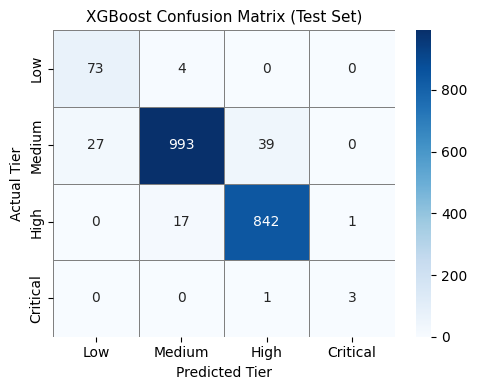

Saved: /content/xgb_confusion_matrix.png


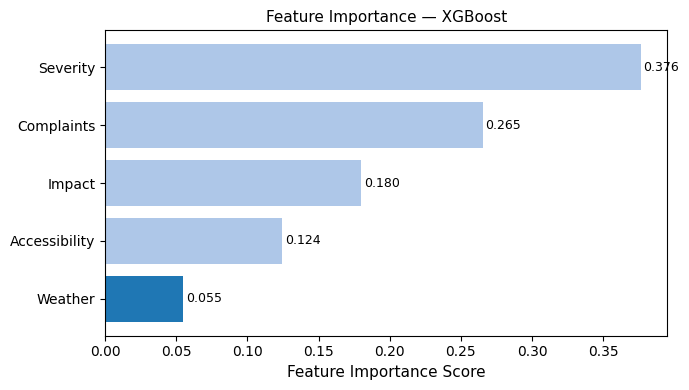

Saved: /content/xgb_feature_importance.png


In [ ]:
# ── Cell 8b: XGBoost ──────────────────────────────────────────────────────
!pip install xgboost --quiet

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost requires numeric labels — encode the tier strings
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

# Compute class weights manually for scale_pos_weight equivalent
# XGBoost handles imbalance via sample_weight
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

# XGBoost classifier
# n_estimators=300: more trees than RF but sequential so less overfit risk
# max_depth=4: shallower than RF default — key regularization
# learning_rate=0.05: slow learning = better generalization
# subsample=0.8: each tree sees 80% of rows (like RF's bagging)
# colsample_bytree=0.8: each tree sees 80% of features
# reg_alpha=0.1: L1 regularization (like Lasso)
# reg_lambda=1.0: L2 regularization (like Ridge)
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    eval_metric='mlogloss',
    verbosity=0
)
xgb.fit(
    X_train, y_train_enc,
    sample_weight=sample_weights
)

y_pred_xgb_enc = xgb.predict(X_test)
y_pred_xgb     = le.inverse_transform(y_pred_xgb_enc)
y_pred_xgb_train_enc = xgb.predict(X_train)

acc_xgb_train = accuracy_score(y_train_enc, y_pred_xgb_train_enc)
acc_xgb_test  = accuracy_score(y_test_enc,  y_pred_xgb_enc)
f1_xgb_train  = f1_score(y_train_enc, y_pred_xgb_train_enc, average='macro')
f1_xgb_test   = f1_score(y_test_enc,  y_pred_xgb_enc,  average='macro')

print('\n=== XGBOOST ===')
print(f'Train Accuracy: {acc_xgb_train:.4f} | Train Macro F1: {f1_xgb_train:.4f}')
print(f'Test  Accuracy: {acc_xgb_test:.4f}  | Test  Macro F1: {f1_xgb_test:.4f}')
print(f'Train/Test F1 gap: {f1_xgb_train - f1_xgb_test:.4f}  '
      f'(RF gap was 0.352 — lower is better)')
print()
print('Classification Report (Test Set):')
print(classification_report(y_test, y_pred_xgb, digits=3))

# ── Updated comparison table ──────────────────────────────────────────────
print('\n=== FINAL MODEL COMPARISON ===')
print(f'{"Model":<30} {"Train F1":>10} {"Test F1":>10} {"Gap":>8}')
print('-' * 62)
print(f'{"Logistic Regression":<30} '
      f'{f1_score(y_train, lr.predict(X_train_sc), average="macro"):>10.3f} '
      f'{f1_score(y_test, y_pred_lr, average="macro"):>10.3f} '
      f'{f1_score(y_train, lr.predict(X_train_sc), average="macro") - f1_score(y_test, y_pred_lr, average="macro"):>8.3f}')
print(f'{"Random Forest":<30} '
      f'{f1_rf_train:>10.3f} '
      f'{f1_rf_test:>10.3f} '
      f'{f1_rf_train - f1_rf_test:>8.3f}')
print(f'{"XGBoost":<30} '
      f'{f1_xgb_train:>10.3f} '
      f'{f1_xgb_test:>10.3f} '
      f'{f1_xgb_train - f1_xgb_test:>8.3f}')

# ── XGBoost confusion matrix ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=CLASS_ORDER)
sns.heatmap(
    cm_xgb, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
    linewidths=0.5, linecolor='gray', ax=ax
)
ax.set_title('XGBoost Confusion Matrix (Test Set)', fontsize=11)
ax.set_xlabel('Predicted Tier', fontsize=10)
ax.set_ylabel('Actual Tier', fontsize=10)
plt.tight_layout()
plt.savefig('/content/xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/xgb_confusion_matrix.png')

# ── XGBoost feature importance ────────────────────────────────────────────
xgb_importances = xgb.feature_importances_
feat_names = ['Severity', 'Weather', 'Impact', 'Complaints', 'Accessibility']
order = np.argsort(xgb_importances)[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(
    [feat_names[i] for i in order][::-1],
    xgb_importances[order][::-1],
    color=['#1f77b4'] + ['#aec7e8'] * 4
)
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Feature Importance — XGBoost', fontsize=11)
for i, val in enumerate(xgb_importances[order][::-1]):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/xgb_feature_importance.png')

## Cell 9 — Figures (Confusion Matrix, Feature Importance, DIR)

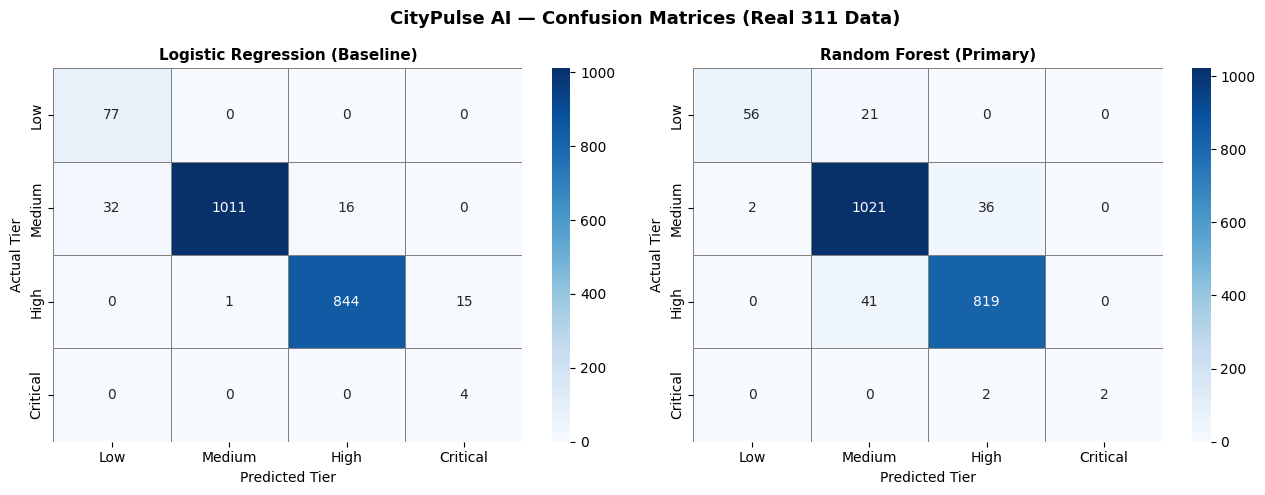

Saved: /content/real_confusion_matrices.png


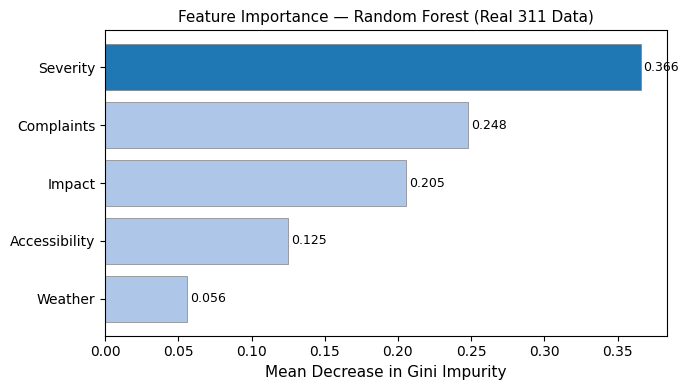

Saved: /content/real_feature_importance.png

=== DISPARATE IMPACT RATIO (Real 311 Data) ===
Reference: Manhattan | P(favorable) = 0.342
  Brooklyn        n= 596  P=0.463  DIR=1.354  PASS ✓
  Queens          n= 655  P=0.437  DIR=1.277  PASS ✓
  Manhattan       n= 307  P=0.342  DIR=1.000  PASS ✓
  Bronx           n= 264  P=0.420  DIR=1.229  PASS ✓
  Staten Island   n= 178  P=0.455  DIR=1.330  PASS ✓


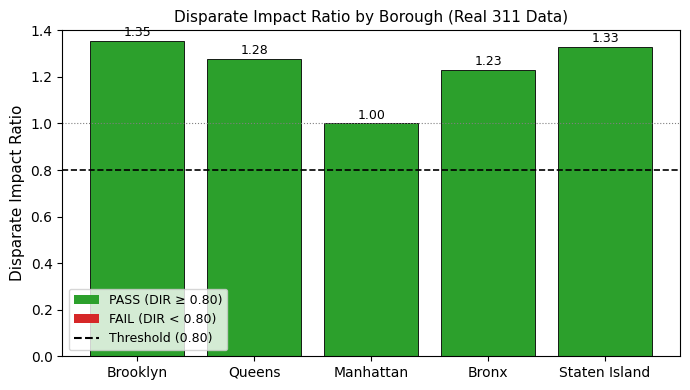

Saved: /content/real_dir_by_borough.png


In [ ]:
CLASS_ORDER = ['Low', 'Medium', 'High', 'Critical']

# ── Figure 1: Side-by-side Confusion Matrices ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CityPulse AI — Confusion Matrices (Real 311 Data)', fontsize=13, fontweight='bold')

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression (Baseline)', 'Random Forest (Primary)']
):
    cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
        linewidths=0.5, linecolor='gray', ax=ax
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Tier', fontsize=10)
    ax.set_ylabel('Actual Tier', fontsize=10)

plt.tight_layout()
plt.savefig('/content/real_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/real_confusion_matrices.png')

# ── Figure 2: Feature Importance ─────────────────────────────────────────
importances  = rf.feature_importances_
feat_names   = ['Severity', 'Weather', 'Impact', 'Complaints', 'Accessibility']
order        = np.argsort(importances)[::-1]
sorted_names = [feat_names[i] for i in order]
sorted_vals  = importances[order]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#1f77b4'] + ['#aec7e8'] * (len(sorted_vals) - 1)
ax.barh(sorted_names[::-1], sorted_vals[::-1],
        color=colors[::-1], edgecolor='gray', linewidth=0.5)
ax.set_xlabel('Mean Decrease in Gini Impurity', fontsize=11)
ax.set_title('Feature Importance — Random Forest (Real 311 Data)', fontsize=11)
for i, (name, val) in enumerate(zip(sorted_names[::-1], sorted_vals[::-1])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/real_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/real_feature_importance.png')

# ── Figure 3: Disparate Impact Ratio ─────────────────────────────────────
df_test = df.iloc[
    df.index[df.index.isin(
        pd.Series(range(len(df))).sample(frac=0.2, random_state=SEED)
    )]
].copy()

# Rebuild test set with borough info attached
test_indices = np.where(np.isin(np.arange(len(df)),
    train_test_split(np.arange(len(df)), test_size=0.2,
                     random_state=SEED,
                     stratify=df[LABEL].values)[1]))[0]
df_test = df.iloc[test_indices].copy()
df_test['pred_rf'] = y_pred_rf

REFERENCE = 'Manhattan'
FAVORABLE = {'Critical', 'High'}
ref_rate  = (df_test[df_test['borough'] == REFERENCE]['pred_rf'].isin(FAVORABLE)).mean()

dir_rows = []
for b in ['Brooklyn', 'Queens', 'Manhattan', 'Bronx', 'Staten Island']:
    sub  = df_test[df_test['borough'] == b]
    rate = sub['pred_rf'].isin(FAVORABLE).mean() if len(sub) > 0 else 0
    dire = rate / ref_rate if ref_rate > 0 else float('nan')
    dir_rows.append({'Borough': b, 'n': len(sub),
                     'rate': rate, 'DIR': dire,
                     'pass': dire >= 0.80})

dir_df = pd.DataFrame(dir_rows)
print('\n=== DISPARATE IMPACT RATIO (Real 311 Data) ===')
print(f'Reference: {REFERENCE} | P(favorable) = {ref_rate:.3f}')
for _, row in dir_df.iterrows():
    status = 'PASS ✓' if row['pass'] else 'FAIL ✗'
    print(f"  {row['Borough']:<15} n={row['n']:>4}  "
          f"P={row['rate']:.3f}  DIR={row['DIR']:.3f}  {status}")

colors_dir = ['#2ca02c' if r else '#d62728' for r in dir_df['pass']]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(dir_df['Borough'], dir_df['DIR'],
              color=colors_dir, edgecolor='black', linewidth=0.6)
ax.axhline(0.80, color='black', linestyle='--', linewidth=1.2, label='Threshold (0.80)')
ax.axhline(1.00, color='gray',  linestyle=':',  linewidth=0.8, label='Reference (Manhattan)')
ax.set_ylabel('Disparate Impact Ratio', fontsize=11)
ax.set_title('Disparate Impact Ratio by Borough (Real 311 Data)', fontsize=11)
ax.set_ylim(0, 1.4)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2ca02c', label='PASS (DIR ≥ 0.80)'),
    Patch(facecolor='#d62728', label='FAIL (DIR < 0.80)'),
    plt.Line2D([0],[0], color='black', linestyle='--', label='Threshold (0.80)'),
], fontsize=9)
for bar, val in zip(bars, dir_df['DIR']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/real_dir_by_borough.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/real_dir_by_borough.png')

## Cell 10 — Save Outputs

In [ ]:
# Save full scored dataset
df.to_csv('/content/citypulse_real_311_scored.csv', index=False)

# Save top 50 priority incidents
df.nlargest(50, 'priority_score').to_csv(
    '/content/citypulse_top50_priority.csv', index=False
)

# Save test predictions
df_test[['unique_key','complaint_type','borough','latitude','longitude',
         'priority_score','priority_tier','pred_rf']].to_csv(
    '/content/citypulse_real_test_predictions.csv', index=False
)

print('Files saved to /content/:')
print('  citypulse_real_311_scored.csv       — full dataset with scores')
print('  citypulse_top50_priority.csv        — top 50 incidents by priority')
print('  citypulse_real_test_predictions.csv — test set predictions')
print('  real_confusion_matrices.png')
print('  real_feature_importance.png')
print('  real_dir_by_borough.png')
print()
print('Download from Files panel (left sidebar) → right-click → Download')
print(f'\nTotal real 311 records processed: {len(df):,}')

Files saved to /content/:
  citypulse_real_311_scored.csv       — full dataset with scores
  citypulse_top50_priority.csv        — top 50 incidents by priority
  citypulse_real_test_predictions.csv — test set predictions
  real_confusion_matrices.png
  real_feature_importance.png
  real_dir_by_borough.png

Download from Files panel (left sidebar) → right-click → Download

Total real 311 records processed: 10,000
